# Day 21

---


In [1]:
import grama as gr
import numpy as np
import scipy as sp
import pandas as pd
import matplotlib.pyplot as plt
DF = gr.Intention()

# Set figure options
plt.rcParams['figure.figsize'] = [6, 6] # Need square aspect ratio for gradients to appear normal
plt.rcParams['figure.dpi'] = 100 # 200 e.g. is really fine, but slower


## Example: Multivariate Gaussian

Let's take another look at the multivariate gaussian.


Estimated runtime: 0.0000 sec


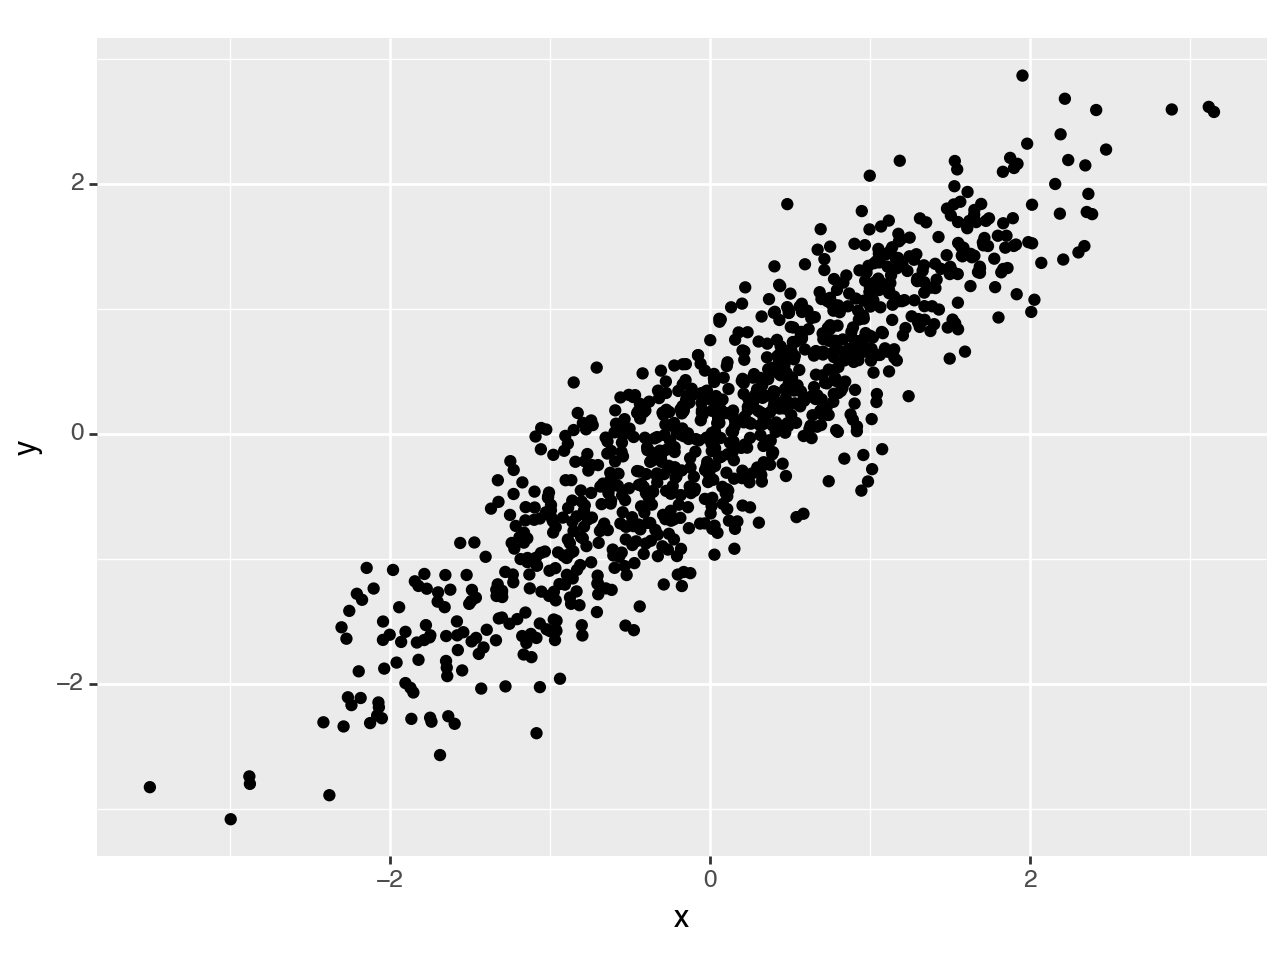

<Figure Size: (640 x 480)>

In [2]:
md_gauss = (
    gr.Model("2d Gaussian")
    >> gr.cp_marginals(
        x=gr.marg_mom("norm", mean=0, sd=1),
        y=gr.marg_mom("norm", mean=0, sd=1),
    )
    >> gr.cp_copula_gaussian(
        df_corr=gr.df_make(
            var1="x", var2="y", corr=0.9,
        )
    )
)

(
    md_gauss
    >> gr.ev_sample(df_det="nom", skip=True, n=1000)
    >> gr.ggplot(gr.aes("x", "y"))
    + gr.geom_point()
)

## Copula

If we apply the marginal CDF to each variable, we can see the copula:

Estimated runtime: 0.0000 sec


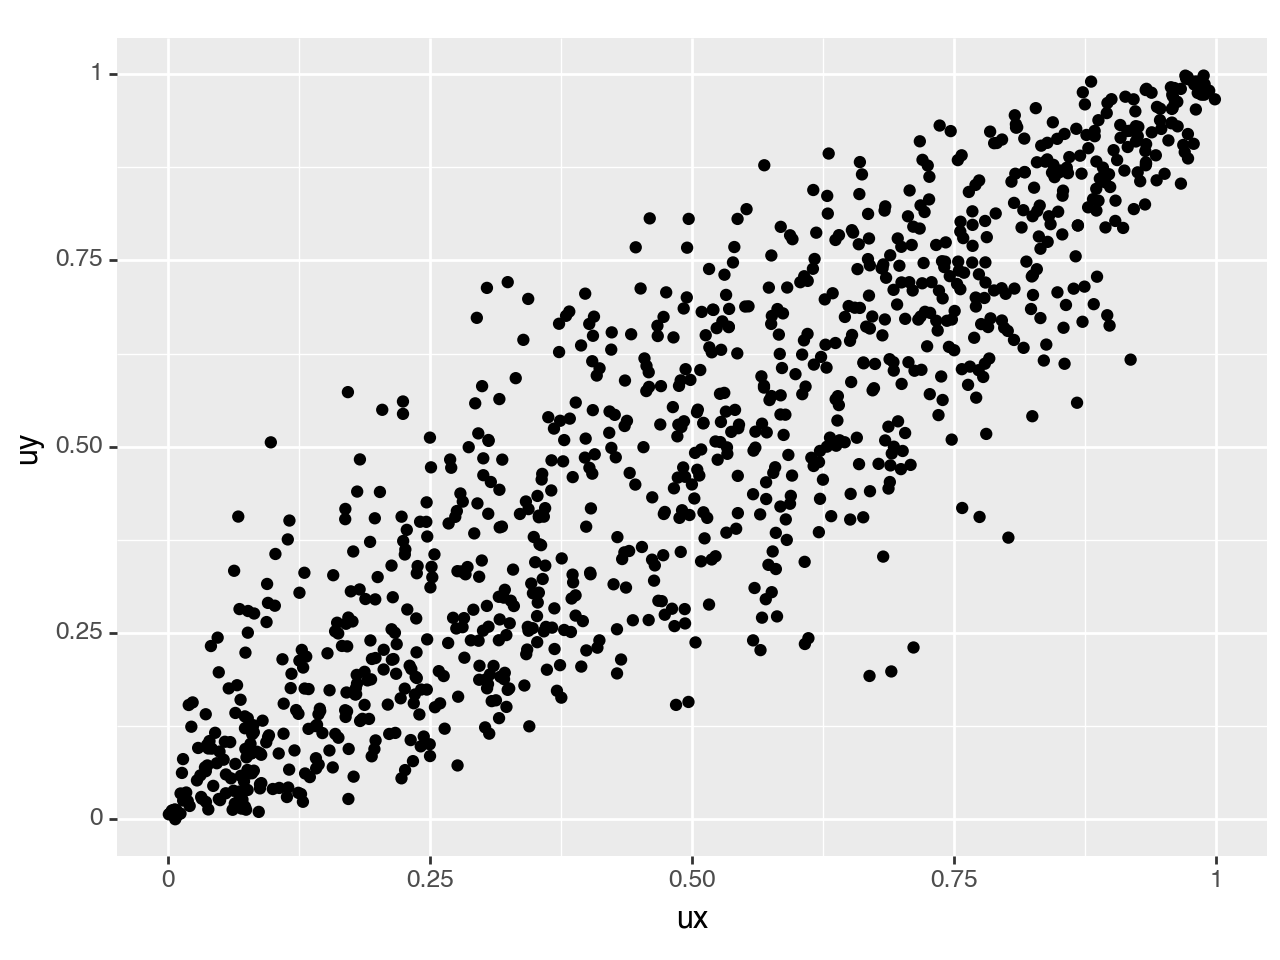

<Figure Size: (640 x 480)>

In [3]:
(
    md_gauss
    >> gr.ev_sample(df_det="nom", skip=True, n=1000)
    # Apply marginal CDFs
    >> gr.tf_mutate(
        ux=md_gauss.density.marginals["x"].p(DF.x),
        uy=md_gauss.density.marginals["y"].p(DF.y),
    )
    
    >> gr.ggplot(gr.aes("ux", "uy"))
    + gr.geom_point()
)

Notice that both variables ux, uy run from [0, 1]. We can inspect the marginals by plotting histograms for each variable.

Estimated runtime: 0.0000 sec


/Users/zach/opt/anaconda3/envs/pdo/lib/python3.9/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 28'. Pick better value with 'binwidth'.


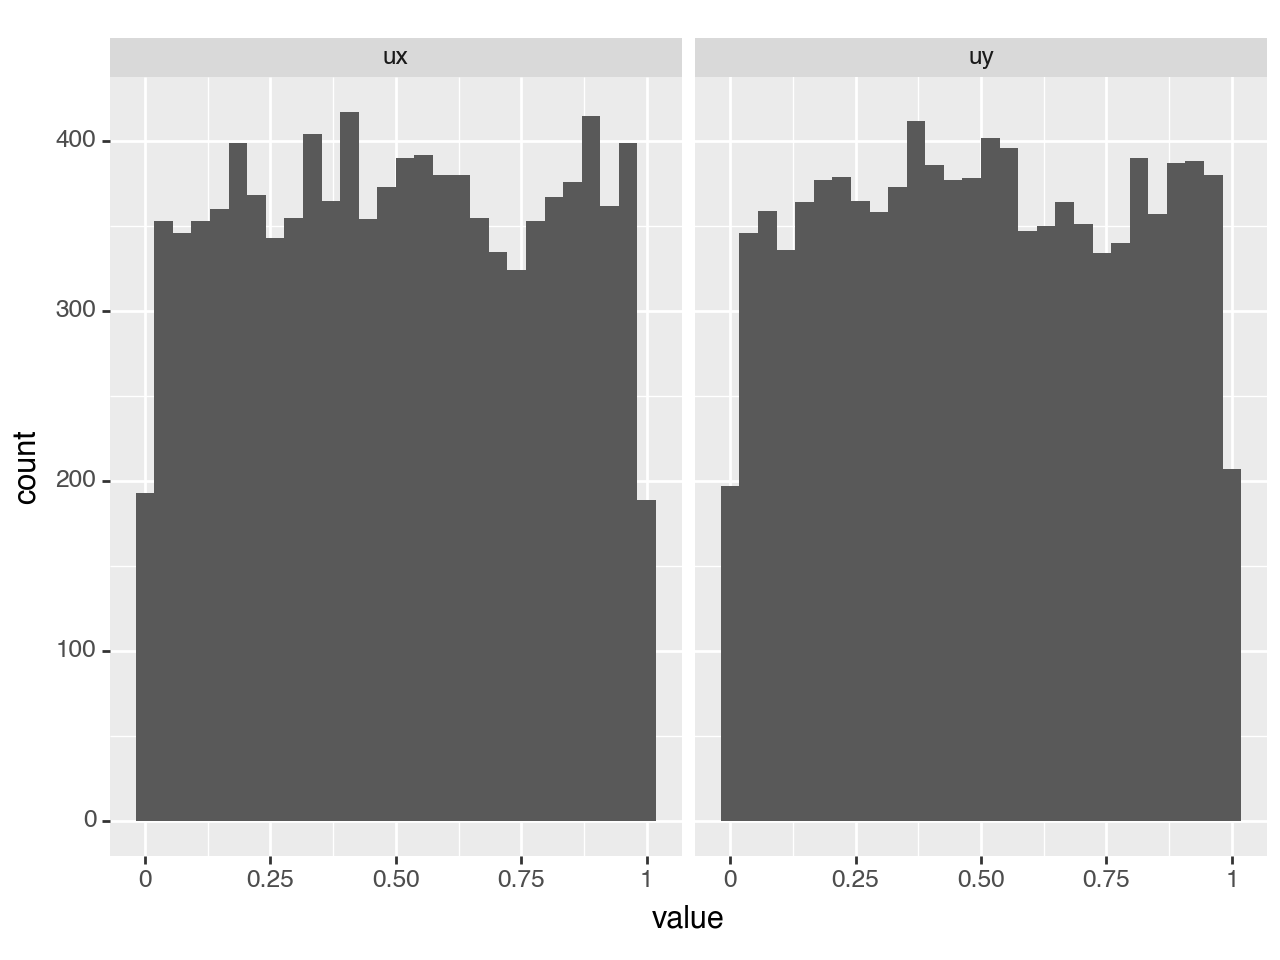

<Figure Size: (640 x 480)>

In [4]:
(
    md_gauss
    >> gr.ev_sample(df_det="nom", skip=True, n=10000)
    # Apply marginal CDFs
    >> gr.tf_mutate(
        ux=md_gauss.density.marginals["x"].p(DF.x),
        uy=md_gauss.density.marginals["y"].p(DF.y),
    )
    >> gr.tf_pivot_longer(
        columns=["ux", "uy"],
        names_to="var",
        values_to="value",
    )
    
    >> gr.ggplot(gr.aes("value"))
    + gr.geom_histogram()
    + gr.facet_wrap("var")
)

These look uniform, as we'd expect.

Estimated runtime: 0.0000 sec


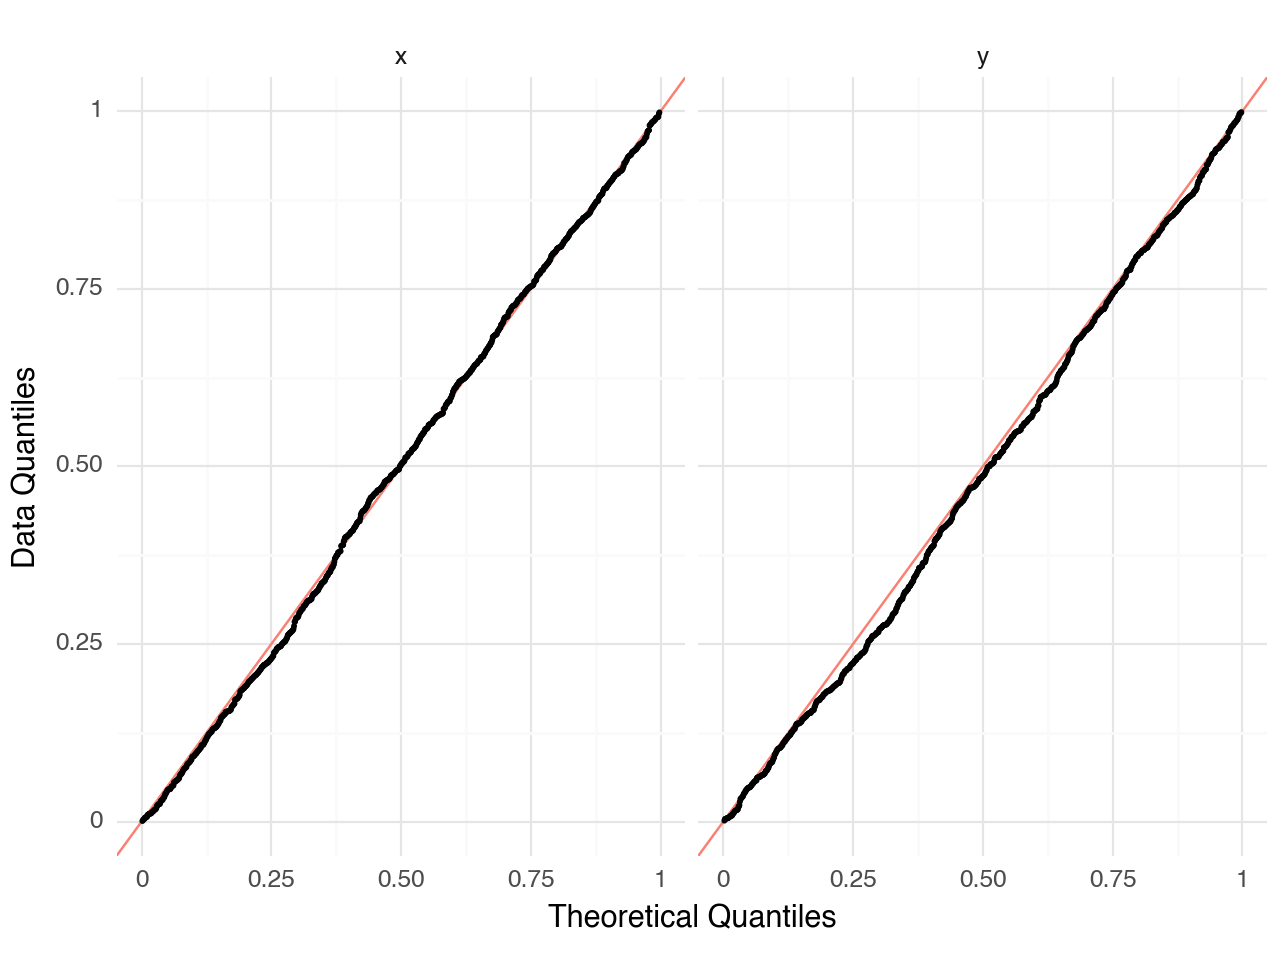

<Figure Size: (640 x 480)>

In [30]:
(
    md_gauss
    >> gr.ev_sample(df_det="nom", skip=True, n=1000)
    # Apply marginal CDFs
    >> gr.tf_mutate(
        ux=md_gauss.density.marginals["x"].p(DF.x),
        uy=md_gauss.density.marginals["y"].p(DF.y),
    )
    # Compute QQ plot data
    >> gr.tf_mutate(
        zx=gr.qqvals(DF.ux, "uniform"),
        zy=gr.qqvals(DF.uy, "uniform"),
    )
    >> gr.tf_select("ux", "uy", "zx", "zy")
    >> gr.tf_pivot_longer(
        columns=["ux", "uy", "zx", "zy"],
        names_pattern=r"(\w)(\w)",
        names_to=[".value", "var"]
    )
    
    >> gr.ggplot(gr.aes("z", "u"))
    + gr.geom_abline(slope=1, intercept=0, color="salmon")
    + gr.geom_point(size=0.2)
    + gr.facet_wrap("var")
    + gr.theme_minimal()
    + gr.labs(
        x="Theoretical Quantiles",
        y="Data Quantiles",
    )
)


The fact that the points lie along the straight reference line means the sample almost exactly matches the shame of the distribution (in our case, uniform).

## Copula-Marginal Model

When we construct a model with `cp_copula_gaussian()`, this is what we're doing:

- Selecting a `marginal` distribution for each variable. This sets the *shape*.
- Selecting a `copula` to represent *dependency* between the variables.

The advantage is that we can select these *separately*.

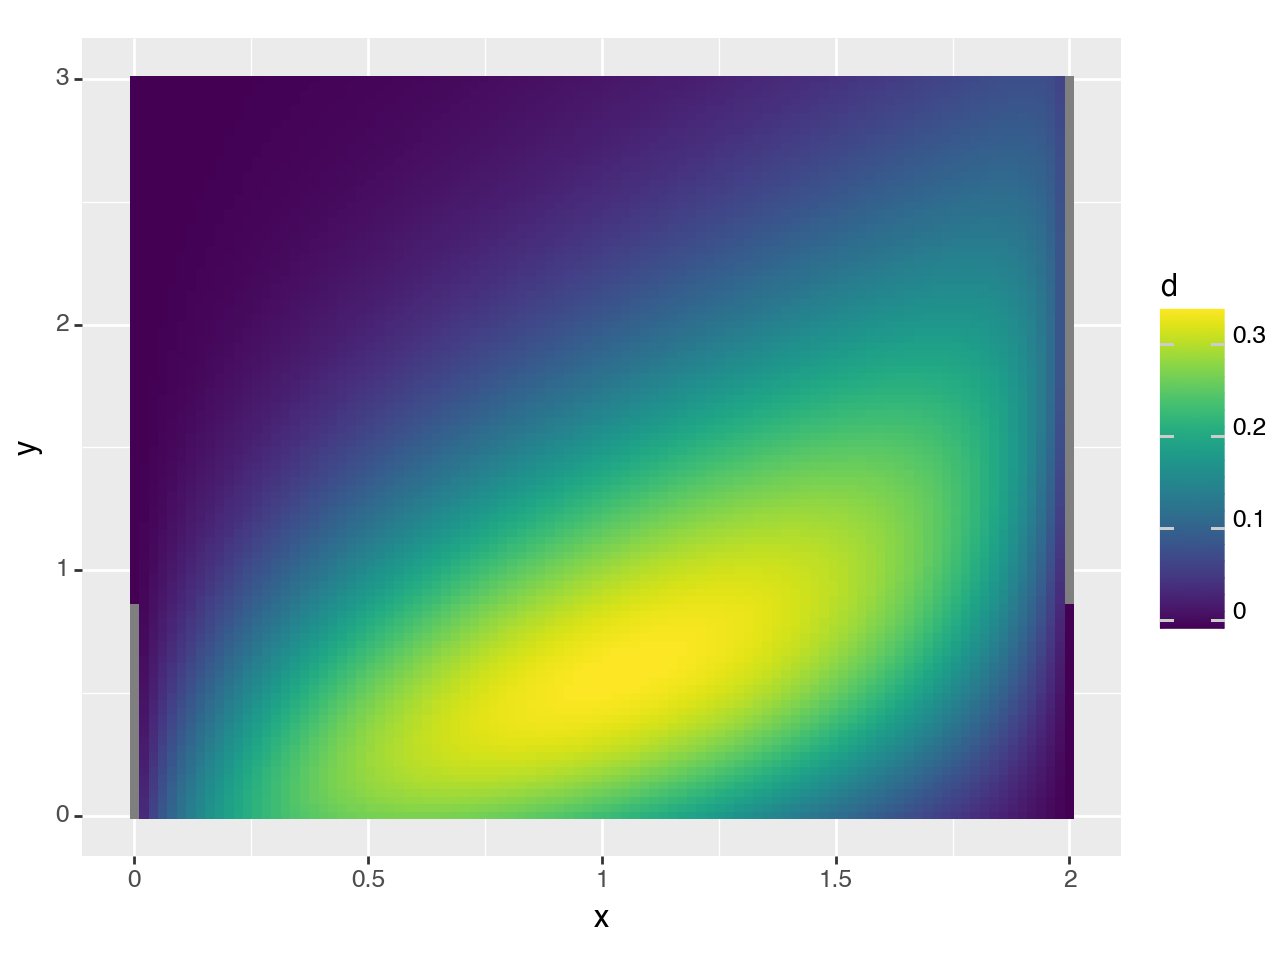

<Figure Size: (640 x 480)>

In [5]:
md_example = (
    gr.Model("Copula-Marginal Model")
    >> gr.cp_marginals(
        x=gr.marg_mom("beta", lo=0, up=+2, mean=1.1, sd=0.5),
        y=gr.marg_mom("lognorm", mean=1, sd=1, skew=1),
    )
    # Specify the correlation structure directly
    >> gr.cp_copula_gaussian(
        df_corr=gr.df_make(
            var1=["x"],
            var2=["y"],
            corr=[0.5],
        )
    )
)

# Evaluate the joint density
df_2d = gr.df_grid(
    x=gr.linspace(0, +2, 100),
    y=gr.linspace(0, +3, 100),
)
df_2d['d'] = md_example.density.d(df_2d[["x", "y"]])

# Plot
(
    df_2d
    >> gr.ggplot(gr.aes("x", "y"))
    + gr.geom_tile(gr.aes(fill="d"))
)

## Worked Example

In [6]:
from grama.data import df_shewhart
df_shewhart.head()

,specimen,tensile_strength,hardness,density
0,1,29314,53.0,2.666
1,2,34860,70.2,2.708
2,3,36818,84.3,2.865
3,4,30120,55.3,2.627
4,5,34020,78.5,2.581


### 1. Inspect marginals

#### `tensile_strength`

/Users/zach/opt/anaconda3/envs/pdo/lib/python3.9/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 7'. Pick better value with 'binwidth'.


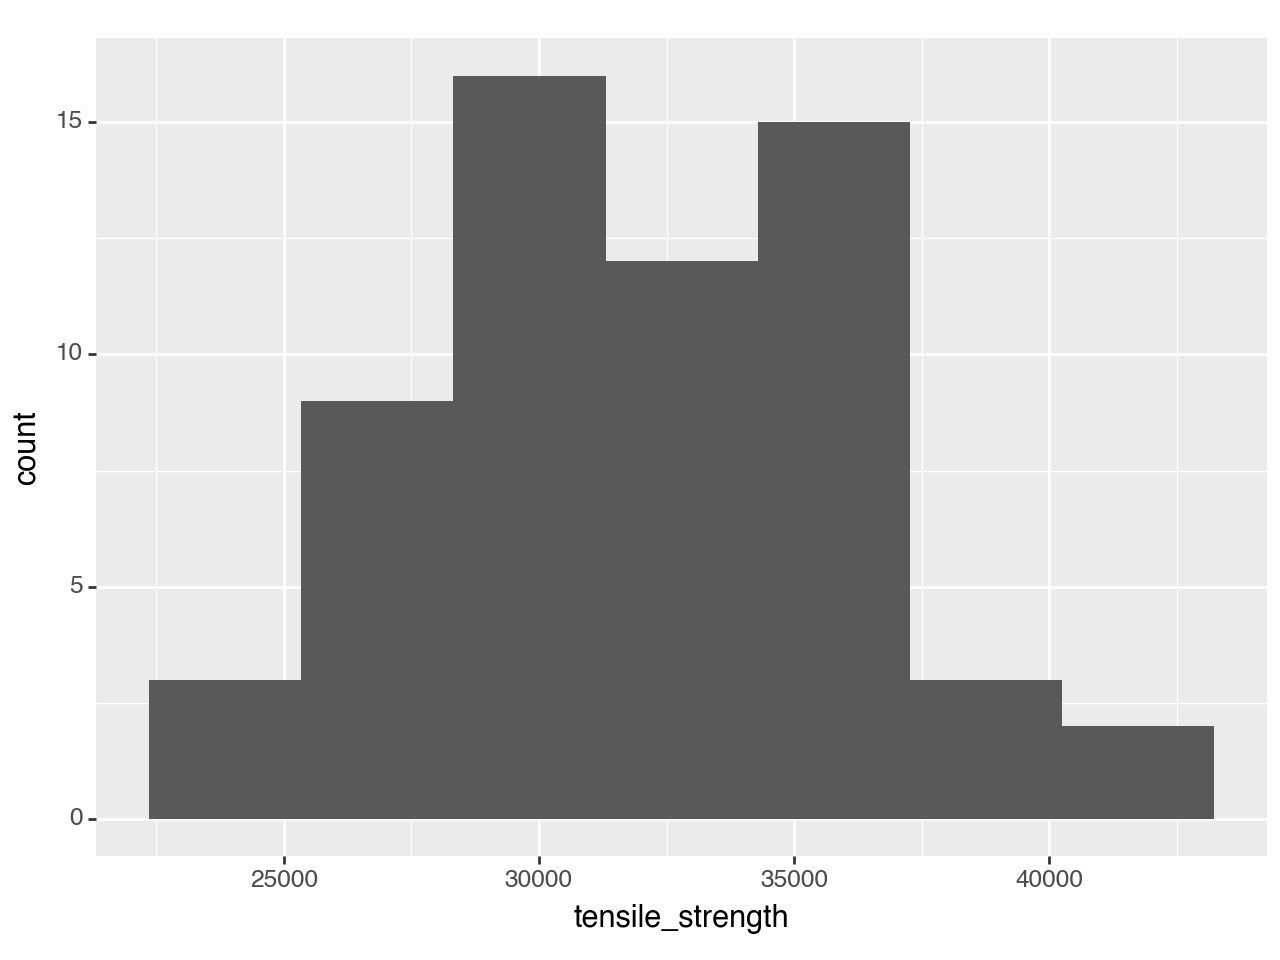

<Figure Size: (640 x 480)>

In [7]:
(
    df_shewhart
    >> gr.ggplot(gr.aes("tensile_strength"))
    + gr.geom_histogram()
)

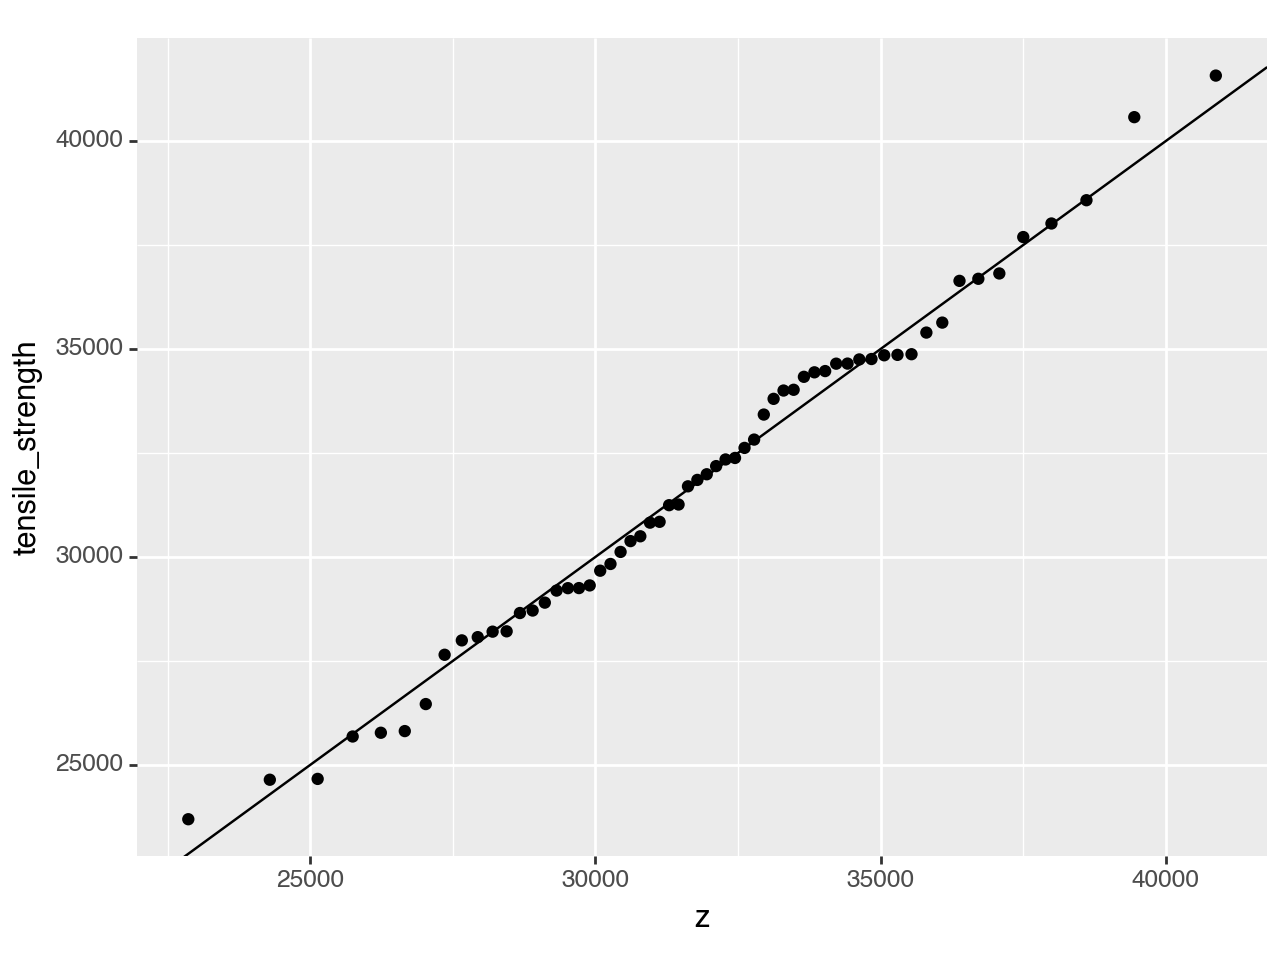

<Figure Size: (640 x 480)>

In [8]:
(
    df_shewhart
    >> gr.tf_mutate(
        z=gr.qqvals(DF.tensile_strength, dist="norm")
        # z=gr.qqvals(DF.tensile_strength, dist="lognorm")
    )
    >> gr.ggplot(gr.aes("z", "tensile_strength"))
    + gr.geom_abline(intercept=0, slope=1)
    + gr.geom_point()
)

#### `hardness`

/Users/zach/opt/anaconda3/envs/pdo/lib/python3.9/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 5'. Pick better value with 'binwidth'.


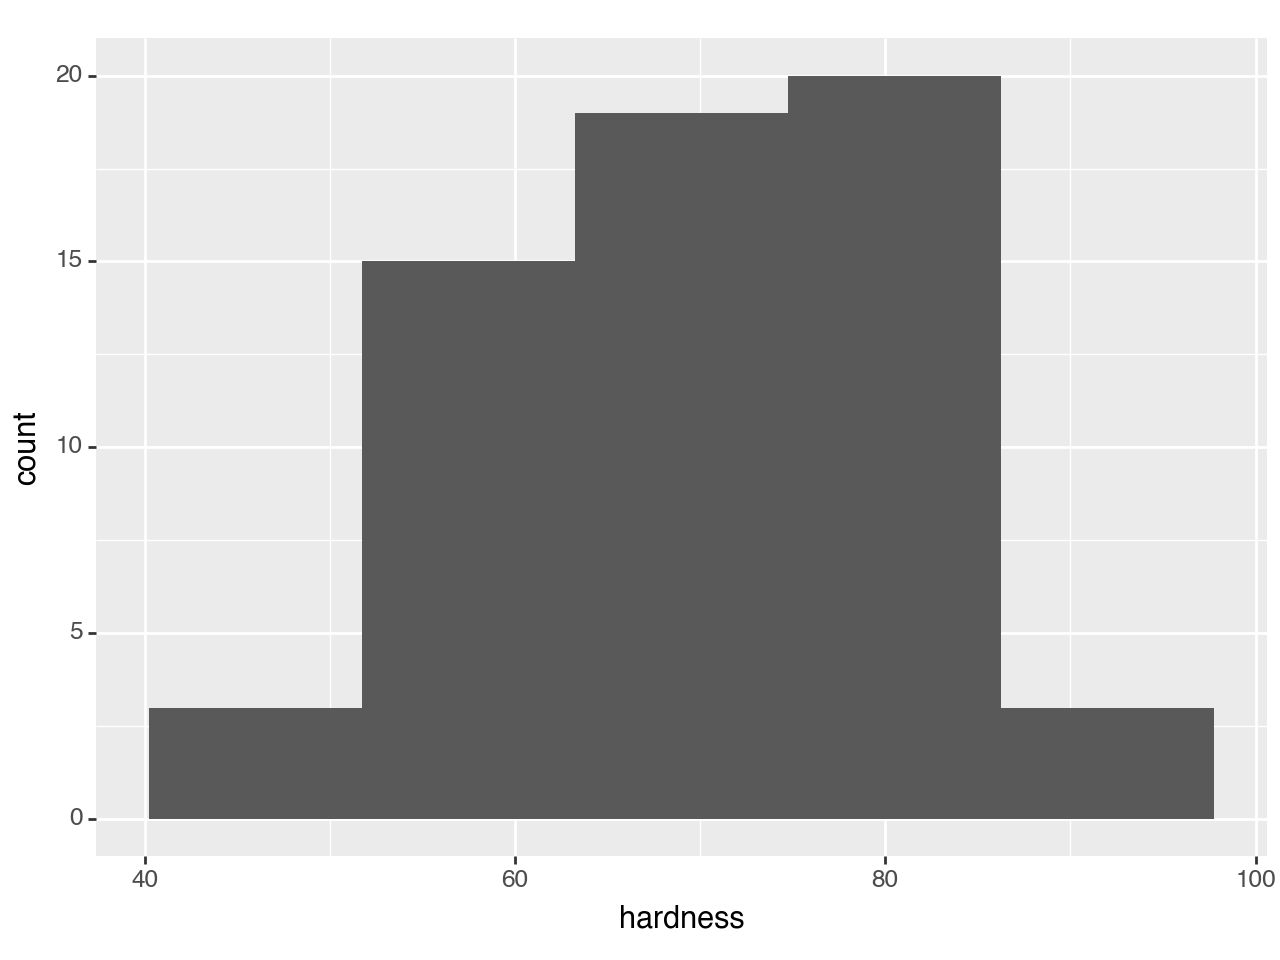

<Figure Size: (640 x 480)>

In [9]:
(
    df_shewhart
    >> gr.ggplot(gr.aes("hardness"))
    + gr.geom_histogram()
)

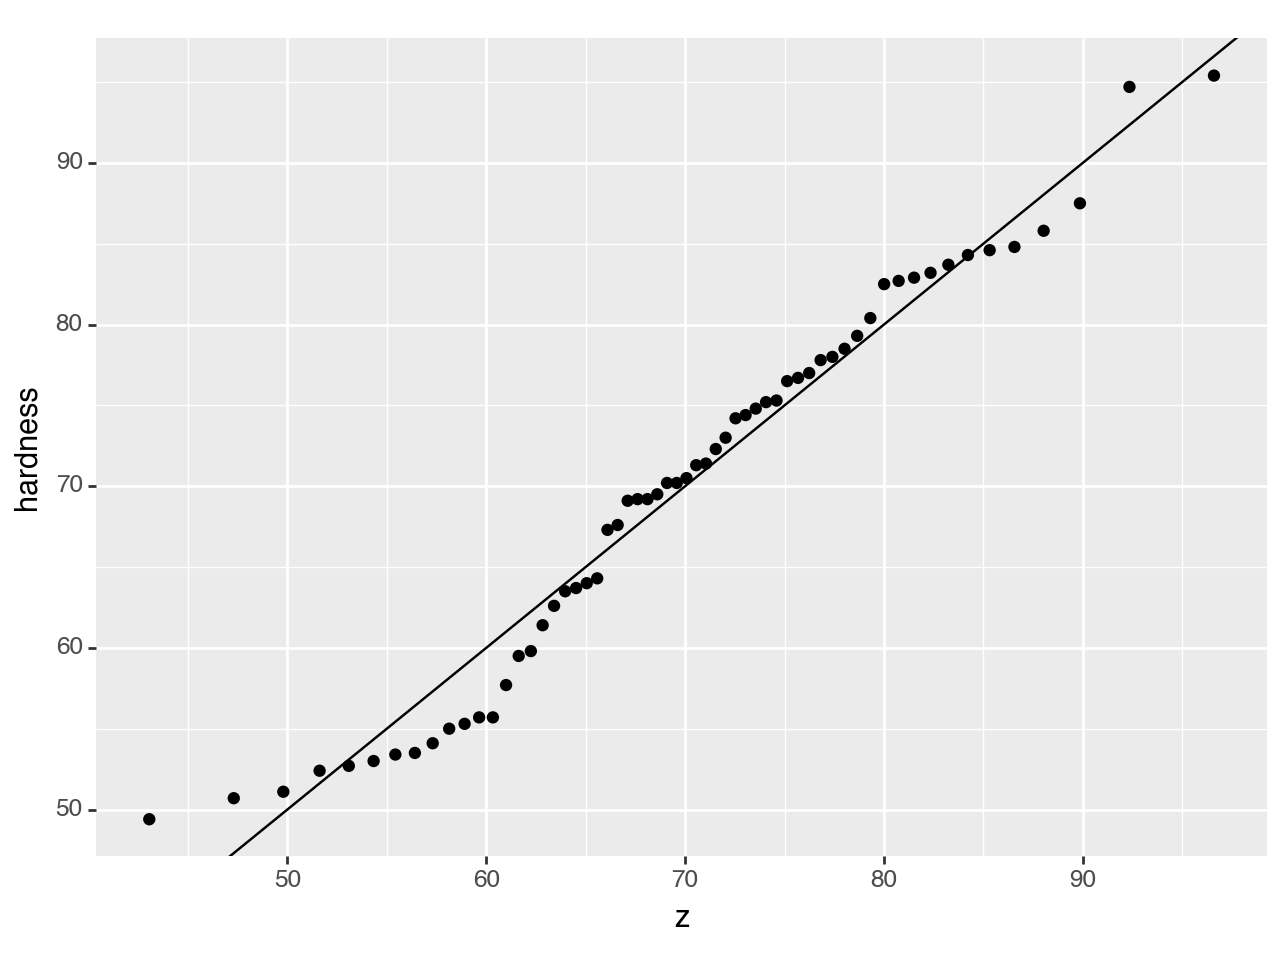

<Figure Size: (640 x 480)>

In [10]:
(
    df_shewhart
    >> gr.tf_mutate(
        z=gr.qqvals(DF.hardness, dist="norm")
        # z=gr.qqvals(DF.hardness, dist="beta")
    )
    >> gr.ggplot(gr.aes("z", "hardness"))
    + gr.geom_abline(intercept=0, slope=1)
    + gr.geom_point()
)

#### `density`

/Users/zach/opt/anaconda3/envs/pdo/lib/python3.9/site-packages/plotnine/stats/stat_bin.py:109: PlotnineWarning: 'stat_bin()' using 'bins = 10'. Pick better value with 'binwidth'.


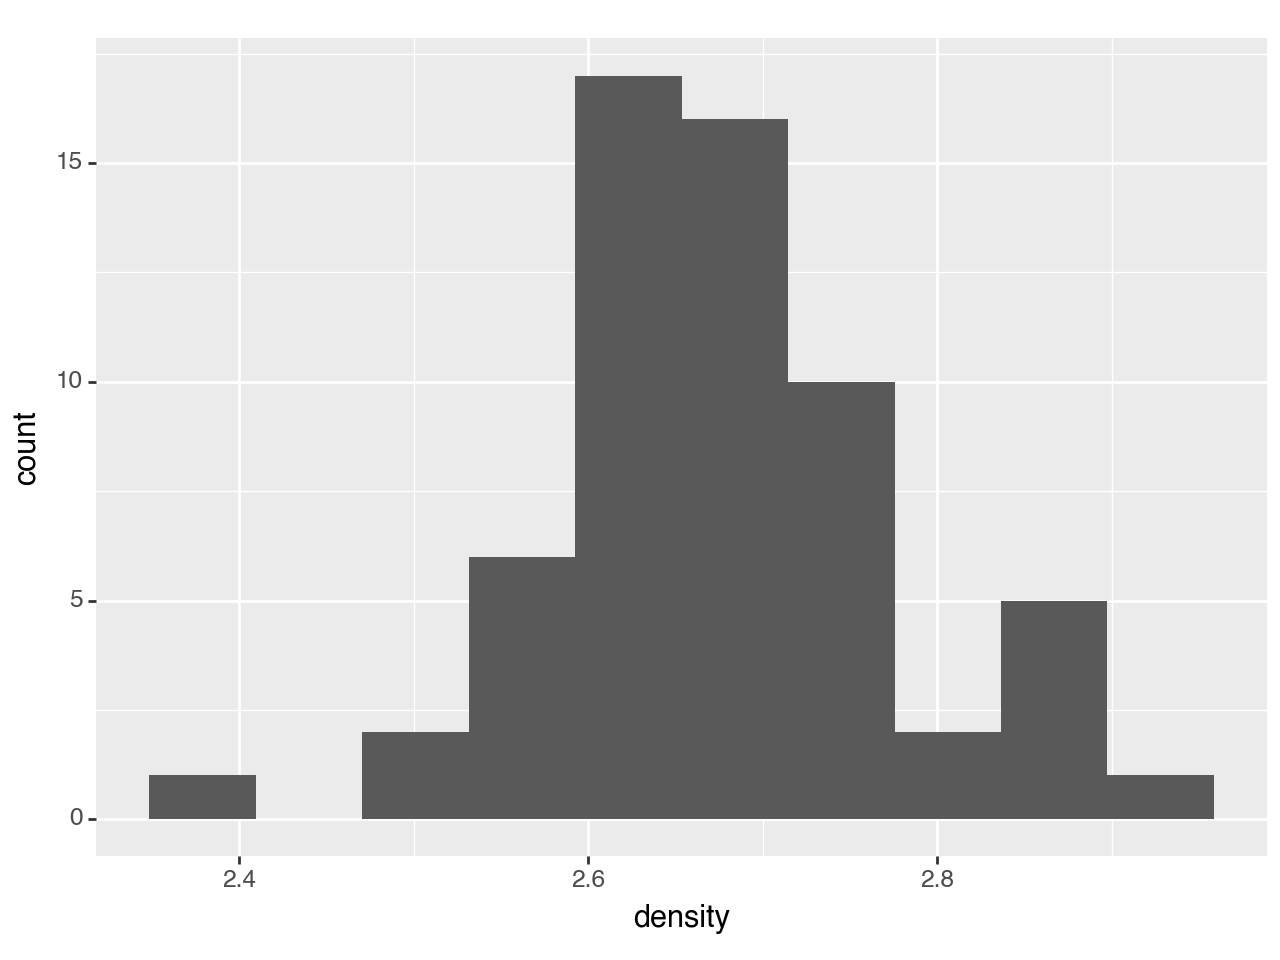

<Figure Size: (640 x 480)>

In [11]:
(
    df_shewhart
    >> gr.ggplot(gr.aes("density"))
    + gr.geom_histogram()
)

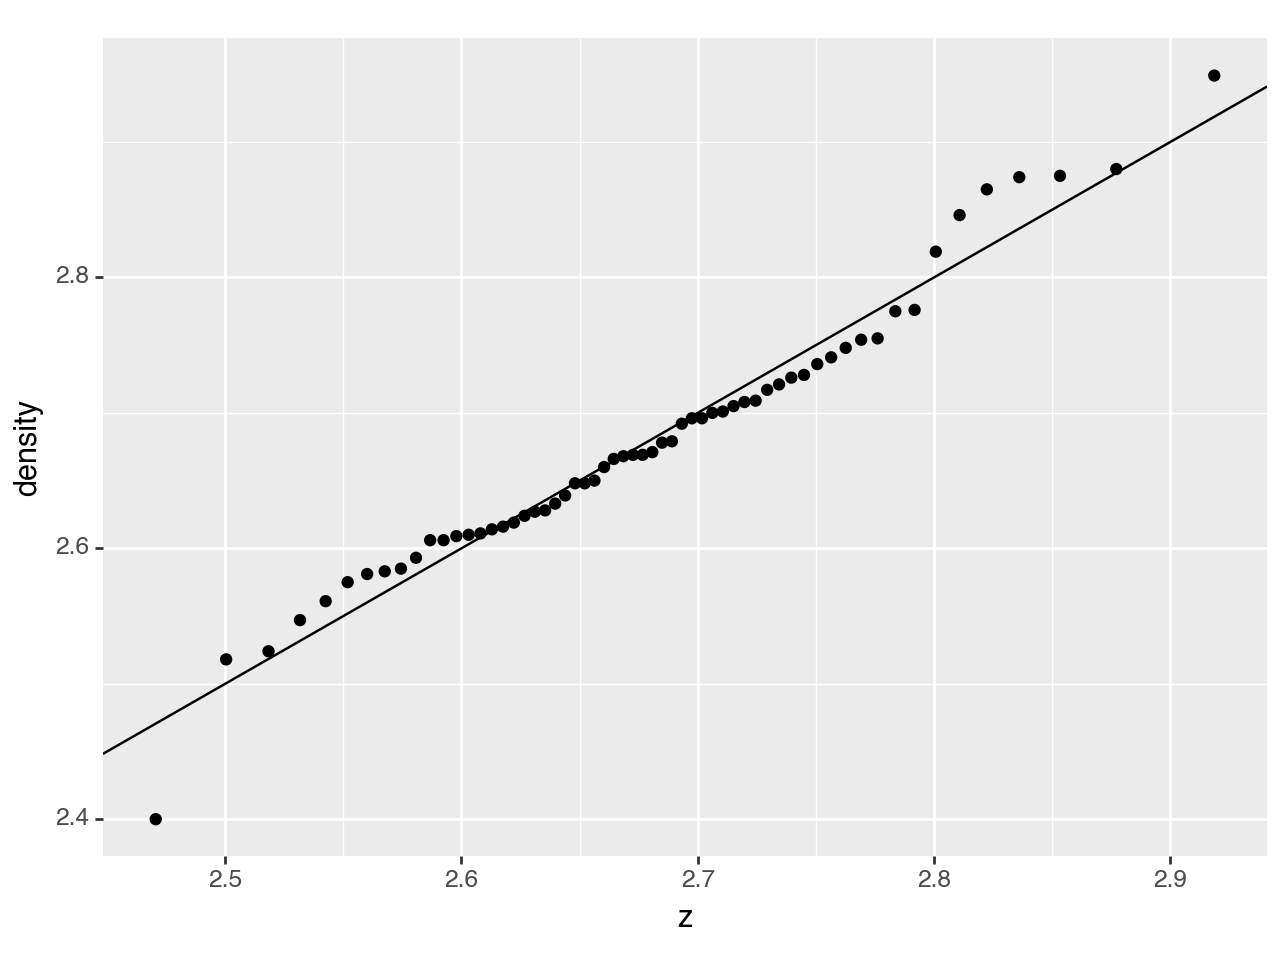

<Figure Size: (640 x 480)>

In [12]:
(
    df_shewhart
    >> gr.tf_mutate(
        z=gr.qqvals(DF.density, dist="beta")
    )
    >> gr.ggplot(gr.aes("z", "density"))
    + gr.geom_abline(intercept=0, slope=1)
    + gr.geom_point()
)

### 2. Fit copula with data

In [13]:
md_shewhart = (
    gr.Model("Material Property Model")
    >> gr.cp_marginals(
        tensile_strength=gr.marg_fit(
            "lognorm",
            df_shewhart.tensile_strength,
        ),
        hardness=gr.marg_fit(
            "beta",
            df_shewhart.hardness,
        ),
        density=gr.marg_fit(
            "beta",
            df_shewhart.density,
        ),
    )
    >> gr.cp_copula_gaussian(df_data=df_shewhart)
)
md_shewhart 

model: Material Property Model

  inputs:
    var_det:

    var_rand:
      tensile_strength: (+0) lognorm, {'mean': '3.187e+04', 's.d.': '3.965e+03', 'COV': 0.12, 'skew.': 0.14, 'kurt.': 3.03}
      hardness: (+0) beta, {'mean': '6.951e+01', 's.d.': '1.232e+01', 'COV': 0.18, 'skew.': 0.23, 'kurt.': 1.99}
      density: (+0) beta, {'mean': '2.680e+00', 's.d.': '1.000e-01', 'COV': 0.04, 'skew.': 0.24, 'kurt.': 3.08}

    copula:
      Gaussian copula with correlations:
               var1              var2      corr
2  tensile_strength          hardness  0.666367
0           density  tensile_strength  0.640576
1           density          hardness  0.581911

  functions:

Estimated runtime: 0.0000 sec


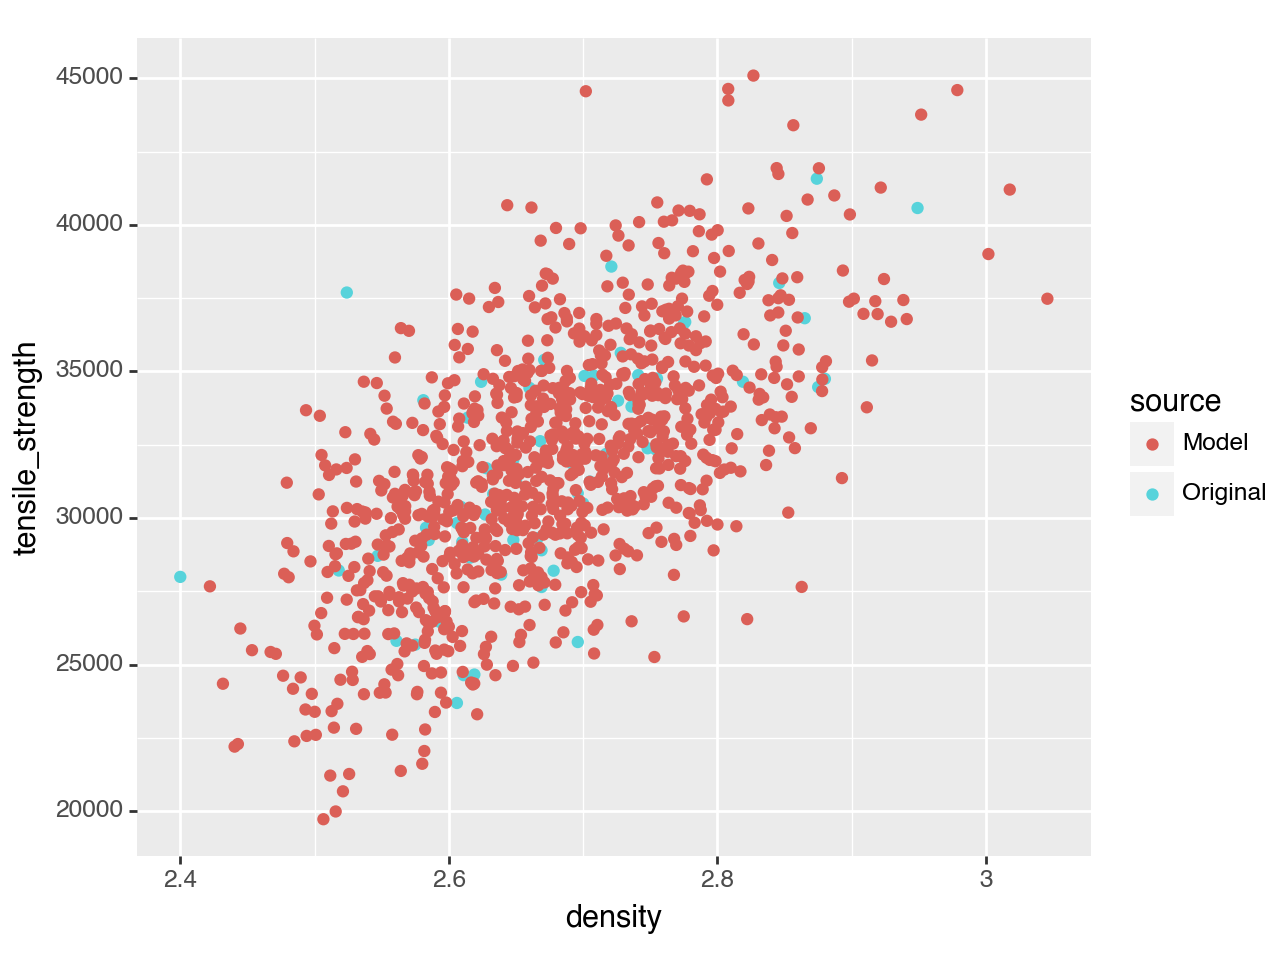

<Figure Size: (640 x 480)>

In [14]:
(
    df_shewhart
    >> gr.tf_mutate(source="Original")
    >> gr.tf_bind_rows(
        md_shewhart
        >> gr.ev_sample(df_det="nom", n=1000, skip=True)
        >> gr.tf_mutate(source="Model")
    )

    >> gr.ggplot(gr.aes("density", "tensile_strength"))
    + gr.geom_point(gr.aes(color="source"))
)